In [1]:
!pip3 install pandas

You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('cymTemp_tag.csv')
print(df)

    target (cym)  eng_at  eng_in  eng_on  cym_yn  cym_wrth  cym_o  cym_ar  \
0             yn       1       0       0       1         0      0       0   
1           wrth       0       1       0       0         1      0       0   
2              o       1       0       0       0         0      1       0   
3             yn       1       0       0       1         0      0       0   
4             ar       0       0       1       0         0      0       1   
..           ...     ...     ...     ...     ...       ...    ...     ...   
162           yn       0       1       0       1         0      0       0   
163           yn       0       1       0       1         0      0       0   
164           yn       0       1       0       1         0      0       0   
165         mewn       0       1       0       0         0      0       0   
166         zero       0       1       0       0         0      0       0   

     cym_zero  cym_pryd  ...  pol_przy  pol_zero  pol_z  pol_o  pol_podczas

In [4]:
df.head()

,target (cym),eng_at,eng_in,eng_on,cym_yn,cym_wrth,cym_o,cym_ar,cym_zero,cym_pryd,...,pol_przy,pol_zero,pol_z,pol_o,pol_podczas,pol_po,pol_zaś,pol_na,_,_x
0,yn,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,wrth,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,o,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,yn,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,ar,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [5]:
features = ['eng_at','eng_in','eng_on','cym_yn','cym_wrth','cym_o','cym_ar','cym_zero','cym_pryd','cym_ymhen','cym_mewn','cym_am','deu_zu','deu_in','deu_an','deu_zero','deu_nach','deu_um','deu__an','deu_bei','deu_von','deu__nach','pol_od','pol_w','pol_przy','pol_zero','pol_z','pol_o','pol_podczas','pol_po','pol_na']
x = df.loc[:, features].values

In [7]:
y = df.loc[:,['target (cym)']].values

In [8]:
x = StandardScaler().fit_transform(x)

In [9]:
pd.DataFrame(data = x, columns = features).head()

,eng_at,eng_in,eng_on,cym_yn,cym_wrth,cym_o,cym_ar,cym_zero,cym_pryd,cym_ymhen,...,deu__nach,pol_od,pol_w,pol_przy,pol_zero,pol_z,pol_o,pol_podczas,pol_po,pol_na
0,1.191759,-0.828775,-0.467951,1.529706,-0.077615,-0.077615,-0.458416,-0.429415,-0.175682,-0.156652,...,-0.077615,-0.135250,-0.808372,-0.252377,-0.347571,-0.077615,-0.156652,-0.175682,-0.13525,-0.193047
1,-0.839096,1.206599,-0.467951,-0.653720,12.884099,-0.077615,-0.458416,-0.429415,-0.175682,-0.156652,...,-0.077615,-0.135250,-0.808372,-0.252377,-0.347571,-0.077615,-0.156652,-0.175682,-0.13525,-0.193047
2,1.191759,-0.828775,-0.467951,-0.653720,-0.077615,12.884099,-0.458416,-0.429415,-0.175682,-0.156652,...,-0.077615,7.393691,-0.808372,-0.252377,-0.347571,-0.077615,-0.156652,-0.175682,-0.13525,-0.193047
3,1.191759,-0.828775,-0.467951,1.529706,-0.077615,-0.077615,-0.458416,-0.429415,-0.175682,-0.156652,...,-0.077615,-0.135250,-0.808372,-0.252377,-0.347571,-0.077615,-0.156652,-0.175682,-0.13525,-0.193047
4,-0.839096,-0.828775,2.136976,-0.653720,-0.077615,-0.077615,2.181426,-0.429415,-0.175682,-0.156652,...,-0.077615,-0.135250,1.237054,-0.252377,-0.347571,-0.077615,-0.156652,-0.175682,-0.13525,-0.193047


In [10]:
pca = PCA(n_components=2)

In [11]:
principalComponents = pca.fit_transform(x)

In [12]:
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

In [13]:
principalDf.head(5)

,principal component 1,principal component 2
0,0.790988,1.643565
1,1.254344,0.482437
2,0.058720,4.279797
3,1.409381,0.259402
4,-3.429278,-1.297551


In [14]:
df[['target (cym)']].head()

,target (cym)
0,yn
1,wrth
2,o
3,yn
4,ar


In [15]:
finalDf = pd.concat([principalDf, df[['target (cym)']]], axis = 1)
finalDf.head(5)

,principal component 1,principal component 2,target (cym)
0,0.790988,1.643565,yn
1,1.254344,0.482437,wrth
2,0.058720,4.279797,o
3,1.409381,0.259402,yn
4,-3.429278,-1.297551,ar


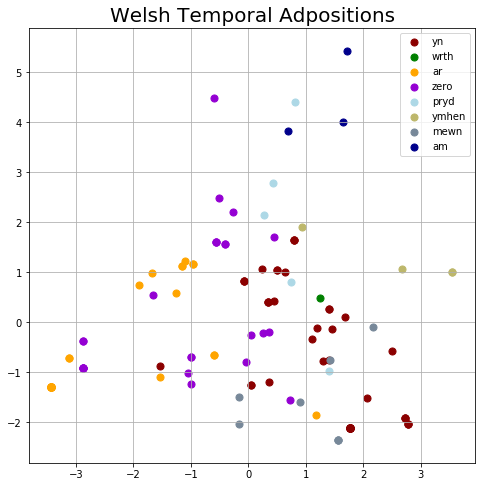

In [23]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_title('Welsh Temporal Adpositions', fontsize = 20)

targets = ['yn','wrth','ar','zero','pryd','ymhen','mewn','am']
colors = ['darkred', 'green', 'orange','darkviolet','lightblue','darkkhaki','lightslategray','darkblue']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target (cym)'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [17]:
pca.explained_variance_ratio_

array([0.1970571 , 0.08700474])